# Partie C — Reproduire la détection de régimes de Wang, Lin & Mikhelson (2020)

Plan :
- **C.1** construction des deux variables du papier sur SPY et standardisation ;
- **C.2** HMM gaussien à 3 états, covariance pleine, janvier 2007 – août 2017 : tableau des
  régimes (Table 3 du papier), matrice de transition (Table 2), figure de classification (Figure 4) ;
- **C.3** choix du nombre d'états par BIC ;
- **C.4** comparaison avec un KMeans et avec une règle de seuil sur la volatilité.

In [1]:
import sys
sys.path.insert(0, "..")
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import adjusted_rand_score

from src.data import load_prices
from src.features import build_features, Standardizer
from src.hmm_model import (fit_hmm, sort_states, expected_durations, stationary_distribution,
                           information_criteria, n_params, filtered_probs, smoothed_probs)
from src.regimes import kmeans_regimes, vol_threshold_regime, persistence_table, n_switches_per_year
from src.pipeline import TRAIN_START, TRAIN_END
from src.plotting import (set_style, savefig, save_table, REGIME_COLORS, REGIME_NAMES, CATEGORICAL,
                          INK_2)

set_style()
pd.set_option("display.precision", 4)
pd.set_option("display.width", 160)

## C.1 — Les deux variables du papier

Section 3.1 du papier :
- **rendement journalier** : $r_t = (P_t - P_{t-1})/P_{t-1}$ (je l'exprime en %, comme la Table 3) ;
- **« volatilité »** : « *the mean squared error (MSE) from the moving average of daily closing prices
  within a 10-day sliding window* », soit $v_t = \frac{1}{10}\sum_{i=0}^{9}(P_{t-i} - \overline{P}_{t})^2$
  où $\overline{P}_t$ est la moyenne mobile 10 jours. **C'est une variance de prix, en dollars².**

J'utilise le **prix de clôture brut** (non ajusté des dividendes) de SPY : le papier parle de données
« OHLC », et je montre plus bas que c'est ce choix qui reproduit ses chiffres.

In [2]:
close_raw = load_prices(adjusted=False)["SPY"]
close_adj = load_prices(adjusted=True)["SPY"]
F_paper = build_features(close_raw, "paper")          # (ret %, vol $^2)
F_real = build_features(close_raw, "realized")        # (ret %, écart-type des rendements sur 10 j, en %)

train = F_paper.loc[TRAIN_START:TRAIN_END]
print(f"Période d'entraînement : {train.index[0].date()} -> {train.index[-1].date()}, {len(train)} jours")
train.describe().T

Période d'entraînement : 2007-01-03 -> 2017-08-31, 2686 jours


,count,mean,std,min,25%,50%,75%,max
ret,2686.0,0.0289,1.2778,-9.8448,-0.4209,0.0545,0.5680,14.5198
vol,2686.0,3.6445,6.0160,0.0551,0.9442,2.0524,4.1764,91.6013


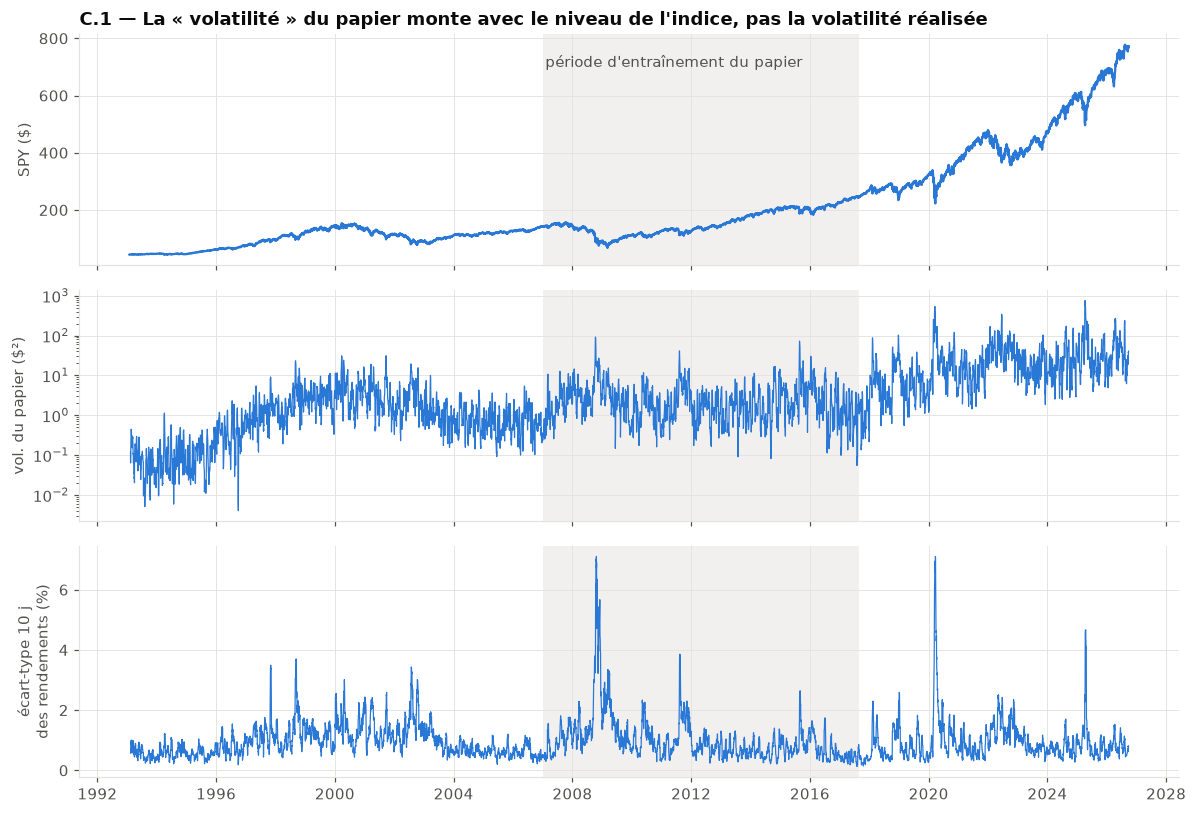

In [3]:
fig, axes = plt.subplots(3, 1, figsize=(11, 7.5), sharex=True)
axes[0].plot(close_raw, color=CATEGORICAL[0])
axes[0].set_ylabel("SPY ($)")
axes[0].set_title("C.1 — La « volatilité » du papier monte avec le niveau de l'indice, pas la volatilité réalisée")
axes[1].plot(F_paper["vol"], color=CATEGORICAL[0], lw=0.8)
axes[1].set_ylabel("vol. du papier ($²)")
axes[1].set_yscale("log")
axes[2].plot(F_real["vol"], color=CATEGORICAL[0], lw=0.8)
axes[2].set_ylabel("écart-type 10 j\ndes rendements (%)")
for ax in axes:
    ax.axvspan(pd.Timestamp(TRAIN_START), pd.Timestamp(TRAIN_END), color="#e4e3df", alpha=0.5, lw=0)
axes[0].text(pd.Timestamp("2011-06-01"), close_raw.max() * 0.9, "période d'entraînement du papier",
             color=INK_2, ha="center")
fig.tight_layout()
savefig(fig, "C1_volatilite_papier_vs_realisee")
plt.show()

**Problème de la définition du papier.** À volatilité relative égale, la variance du prix est
proportionnelle au **carré du prix**. SPY valait ≈ 70 $ en mars 2009 et ≈ 250 $ en 2017, soit un
facteur $(250/70)^2 \approx 13$ sur cette variable pour une même agitation du marché (le test
`test_paper_vol_depends_on_price_level_but_realized_does_not` le vérifie : prix × 5 ⇒ variable × 25).
En échelle log (panneau du milieu), la variable du papier dérive vers le haut avec l'indice,
alors que l'écart-type des rendements (panneau du bas) revient toujours vers le même niveau.
Dans l'échantillon d'entraînement, cette dérive est en partie masquée par la crise de 2008 ;
hors échantillon, avec SPY entre 250 et 650 $, elle devient un vrai problème (partie D).

### Standardisation

Les deux variables ont des échelles très différentes : écart-type ≈ 1,3 pour le rendement, ≈ 6
pour la « volatilité », qui est en plus très asymétrique (max ≈ 92). Je les centre-réduis avec
la moyenne et l'écart-type **de la période d'entraînement uniquement** (`Standardizer`), pour
trois raisons pratiques :
1. `hmmlearn` initialise les moyennes des états par un **KMeans**, qui repose sur des distances
   euclidiennes : sans standardisation, la variable de plus grande échelle dicte seule l'initialisation ;
2. `hmmlearn` ajoute un plancher `min_covar = 1e-3` à toutes les variances, dans les unités des
   données : ce plancher n'a pas le même effet sur une variable d'écart-type 1 et sur une de 6 ;
3. le conditionnement numérique des matrices de covariance est meilleur.

**En théorie**, un HMM gaussien à covariance pleine est invariant par transformation affine des
variables : si $z = (x - m)/s$, le maximum de vraisemblance sur $z$ est l'image du maximum sur $x$,
et la classification est la même. Je le vérifie ci-dessous. C'est différent pour le **KMeans**
(C.4), qui dépend fortement de l'échelle.

In [4]:
scaler = Standardizer().fit(train)
Z = scaler.transform(train)

hmm_std = fit_hmm(Z.values, 3, n_init=10)
hmm_std, _ = sort_states(hmm_std, "mean", feature=1)
hmm_raw = fit_hmm(train.values, 3, n_init=10)
hmm_raw, _ = sort_states(hmm_raw, "mean", feature=1)

lab_std, lab_raw = hmm_std.predict(Z.values), hmm_raw.predict(train.values)
jac = np.log(scaler.std_).sum() * len(train)     # jacobien du changement de variable
print(f"Log-vraisemblance données standardisées, ramenée aux unités brutes : {hmm_std.score(Z.values) - jac:.2f}")
print(f"Log-vraisemblance données brutes                                 : {hmm_raw.score(train.values):.2f}")
print(f"Jours classés identiquement (Viterbi) : {np.mean(lab_std == lab_raw):.2%}")

Log-vraisemblance données standardisées, ramenée aux unités brutes : -8614.62
Log-vraisemblance données brutes                                 : -8614.62
Jours classés identiquement (Viterbi) : 99.96%


Les deux estimations aboutissent au même optimum (même vraisemblance une fois le jacobien
du changement de variable pris en compte) et à la même classification : ici, la standardisation
ne change rien au résultat, mais elle rend l'estimation plus robuste (initialisation, plancher de
variance), et elle est **indispensable** pour le KMeans de C.4. Je garde donc la version standardisée.

## C.2 — HMM à 3 états, covariance pleine, 2007 – 2017

Réglages du papier : 3 états, covariance pleine, `n_iter = 75`. J'ajoute 10 initialisations (B.3)
et je trie les états par volatilité moyenne croissante (B.4). Le papier numérote ses régimes
autrement (0 = « kangaroo », 1 = bull, 2 = bear) : j'indique la correspondance dans les tableaux.

In [5]:
hmm75, lls, _ = fit_hmm(Z.values, 3, n_init=10, n_iter=75, tol=1e-2, return_all=True)
print("Log-vraisemblance des 10 initialisations :", np.round(lls, 2))
print(f"EM convergé : {hmm75.monitor_.converged} en {hmm75.monitor_.iter} itérations (limite du papier : 75)")
model, perm = sort_states(hmm75, "mean", feature=1)

viterbi = pd.Series(model.predict(Z.values), index=train.index)
filt = pd.DataFrame(filtered_probs(model, Z.values), index=train.index)
smooth = pd.DataFrame(smoothed_probs(model, Z.values), index=train.index)

PAPER_LABEL = {0: "1 (bull)", 1: "0 (kangaroo)", 2: "2 (bear)"}     # mon état -> numéro du papier
PAPER_T3 = pd.DataFrame({"freq_papier": [0.4463, 0.4237, 0.13],
                         "ret_papier": [0.04635, 0.0398, -0.066],
                         "vol_papier": [0.9438, 3.4739, 13.63465]}, index=[0, 1, 2])

def regime_table(labels, data):
    g = data.groupby(labels.values)
    return pd.DataFrame({"freq": labels.value_counts(normalize=True).sort_index(),
                         "ret_moyen_%": g["ret"].mean(), "vol_moyenne": g["vol"].mean()})

t3 = regime_table(viterbi, train).join(PAPER_T3)
t3.insert(0, "régime papier", [PAPER_LABEL[k] for k in t3.index])
t3.insert(0, "nom", [REGIME_NAMES[k] for k in t3.index])
t3 = t3[["nom", "régime papier", "freq", "freq_papier", "ret_moyen_%", "ret_papier", "vol_moyenne", "vol_papier"]]
save_table(t3, "C2_table3_regimes_vs_papier", ".4f")
t3

Log-vraisemblance des 10 initialisations : [-3137.3  -3137.31 -3137.31 -3137.32 -3137.32 -3137.32 -3137.32 -3137.32
 -3137.32 -3137.32]
EM convergé : True en 57 itérations (limite du papier : 75)


,nom,régime papier,freq,freq_papier,ret_moyen_%,ret_papier,vol_moyenne,vol_papier
0,calme,1 (bull),0.4464,0.4463,0.0445,0.0464,0.9358,0.9438
1,intermédiaire,0 (kangaroo),0.4252,0.4237,0.0413,0.0398,3.4704,3.4739
2,crise,2 (bear),0.1284,0.1300,-0.0660,-0.0660,13.6347,13.6347


**La réplication est quasi exacte** : fréquences 44,6 / 42,5 / 12,8 % (papier : 44,6 / 42,4 / 13,0 %),
rendements moyens +0,045 / +0,041 / −0,066 % (papier : +0,046 / +0,040 / −0,066 %), volatilités
moyennes 0,94 / 3,47 / 13,63 $² (papier : 0,94 / 3,47 / 13,63 $²). La volatilité moyenne du régime
baissier est identique à la 4e décimale (13,6347).
Les petits écarts viennent de la fenêtre exacte (le papier dit « jusqu'à septembre 2017 », soit
quelques jours de plus que ma fin au 31 août) et d'éventuelles révisions de données Yahoo.

Cela confirme la lecture de la section 3.1 : les auteurs ont bien utilisé la variance du **prix
brut** sur 10 jours, et classé les jours avec **Viterbi** (`predict`), c'est-à-dire en utilisant
toute la série. Je vérifie ci-dessous l'effet du choix du prix (brut ou ajusté) et du mode de
classification (Viterbi, lissé, filtré).

In [6]:
F_adj = build_features(close_adj, "paper").loc[TRAIN_START:TRAIN_END]
Z_adj = Standardizer().fit_transform(F_adj)
m_adj, _ = sort_states(fit_hmm(Z_adj.values, 3, n_init=10, n_iter=75, tol=1e-2), "mean", 1)
lab_adj = pd.Series(m_adj.predict(Z_adj.values), index=F_adj.index)

variantes = pd.concat({
    "prix brut, Viterbi (= papier)": regime_table(viterbi, train),
    "prix brut, lissée (argmax)": regime_table(pd.Series(smooth.values.argmax(1), index=train.index), train),
    "prix brut, filtrée (argmax)": regime_table(pd.Series(filt.values.argmax(1), index=train.index), train),
    "prix ajusté, Viterbi": regime_table(lab_adj, F_adj),
}, names=["variante", "régime"])
save_table(variantes, "C2_variantes_prix_classification", ".4f")
variantes

freq  ret_moyen_%  vol_moyenne
variante                      régime                                  
prix brut, Viterbi (= papier) 0       0.4464       0.0445       0.9358
                              1       0.4252       0.0413       3.4704
                              2       0.1284      -0.0660      13.6347
prix brut, lissée (argmax)    0       0.4423       0.0384       0.9264
                              1       0.4281       0.0500       3.4446
                              2       0.1296      -0.0731      13.5842
prix brut, filtrée (argmax)   0       0.4367       0.0527       0.9221
                              1       0.4352       0.0318       3.4382
                              2       0.1281      -0.0618      13.6287
prix ajusté, Viterbi          0       0.4531       0.0580       0.5826
                              1       0.4315       0.0453       2.1752
                              2       0.1154      -0.0760       8.6562

- Avec le **prix ajusté** des dividendes, les prix passés sont plus bas, donc la variable « vol »
  aussi : la volatilité moyenne des régimes s'écarte nettement de celle du papier. C'est un indice
  de plus que le papier a utilisé le prix brut, et un symptôme du problème d'unité ($²) : un
  simple changement de base des prix modifie la variable.
- **Viterbi et probabilités lissées** donnent presque le même découpage. La **probabilité filtrée**
  (la seule utilisable pour trader) classe un peu différemment : elle ne voit pas le futur.

### Matrice de transition (Table 2 du papier) et durées moyennes

In [7]:
A_mine = pd.DataFrame(model.transmat_, index=[f"de {REGIME_NAMES[k]}" for k in range(3)],
                      columns=[f"vers {REGIME_NAMES[k]}" for k in range(3)])
# Table 2 du papier réordonnée dans MON ordre (calme = leur 1, intermédiaire = leur 0, crise = leur 2)
A_paper_raw = np.array([[9.019e-1, 6.472e-2, 3.32960344e-2],
                        [6.144e-2, 9.385e-1, 1.91529674e-29],
                        [1.085e-1, 5.466e-70, 8.914e-1]])
order = [1, 0, 2]
A_paper = pd.DataFrame(A_paper_raw[np.ix_(order, order)], index=A_mine.index, columns=A_mine.columns)
save_table(A_mine, "C2_transition_mienne", ".4f")
print("Ma matrice de transition :")
display(A_mine.round(4))
print("Table 2 du papier, réordonnée dans le même ordre :")
display(A_paper.round(4))

dur = pd.DataFrame({
    "a_kk (moi)": np.diag(model.transmat_), "durée moy. (moi, j)": expected_durations(model.transmat_),
    "a_kk (papier)": np.diag(A_paper.values), "durée moy. (papier, j)": expected_durations(A_paper.values),
    "loi stationnaire (moi)": stationary_distribution(model.transmat_),
    "loi stationnaire (papier)": stationary_distribution(A_paper.values),
}, index=[REGIME_NAMES[k] for k in range(3)])
save_table(dur, "C2_durees_moyennes", ".3f")
dur

Ma matrice de transition :


,vers calme,vers intermédiaire,vers crise
de calme,0.9375,0.0625,0.0000
de intermédiaire,0.0635,0.9034,0.0331
de crise,0.0000,0.1083,0.8917


Table 2 du papier, réordonnée dans le même ordre :


,vers calme,vers intermédiaire,vers crise
de calme,0.9385,0.0614,0.0000
de intermédiaire,0.0647,0.9019,0.0333
de crise,0.0000,0.1085,0.8914


,a_kk (moi),"durée moy. (moi, j)",a_kk (papier),"durée moy. (papier, j)",loi stationnaire (moi),loi stationnaire (papier)
calme,0.9375,16.0102,0.9385,16.2602,0.4376,0.4464
intermédiaire,0.9034,10.3537,0.9019,10.1937,0.4307,0.4236
crise,0.8917,9.2342,0.8914,9.2081,0.1317,0.1300


In [8]:
w_dur = (dur["loi stationnaire (papier)"] * dur["durée moy. (papier, j)"]).sum()
w_dur_mine = (dur["loi stationnaire (moi)"] * dur["durée moy. (moi, j)"]).sum()
spell_len = len(viterbi) / (viterbi.ne(viterbi.shift()).sum())
print(f"Durée moyenne pondérée par la loi stationnaire : papier {w_dur:.1f} j, moi {w_dur_mine:.1f} j")
print(f"Longueur moyenne d'un épisode Viterbi (T / nb d'épisodes) : {spell_len:.1f} j")
print("Loi initiale estimée pi :", model.startprob_.round(4))

Durée moyenne pondérée par la loi stationnaire : papier 12.8 j, moi 12.7 j
Longueur moyenne d'un épisode Viterbi (T / nb d'épisodes) : 12.5 j
Loi initiale estimée pi : [1. 0. 0.]


**Lecture de la matrice.**
- Les probabilités de rester sont de 0,90 à 0,94 : durées moyennes $1/(1-a_{kk})$ de **16 jours**
  (calme), **10 jours** (intermédiaire) et **9 jours** (crise), identiques au papier.
- La structure est **« en chaîne »** : calme ↔ intermédiaire ↔ crise. On ne passe jamais directement
  du calme à la crise ni de la crise au calme (probabilités ≈ 10⁻²⁹ et 10⁻⁷⁰ dans le papier, 0
  chez moi). C'est logique : la variable « vol » est une variance sur 10 jours glissants, elle ne
  peut pas sauter d'un niveau bas à un niveau très haut en un jour.
- La longueur moyenne d'un épisode du chemin de Viterbi vaut **12,5 jours** (et la durée moyenne
  pondérée par la loi stationnaire 12,7 jours) : c'est exactement l'« *average continuous regime
  period of approximately 12.5 days* » du papier. Les auteurs l'attribuent au réglage
  `n_iter = 75`, mais l'EM converge en 57 itérations, avant la limite. Ce paramètre ne joue
  donc aucun rôle : la persistance vient des données, pas du réglage.
- La loi initiale (Table 1 du papier : 1 sur un état, 10⁻⁹¹ ailleurs) est dégénérée, chez moi comme
  chez eux : avec une seule série, $\pi$ est estimé par la probabilité a posteriori du premier jour,
  qui vaut presque toujours 0 ou 1. Ce tableau n'a aucun intérêt économique.

### Figure 4 du papier : classification du S&P 500

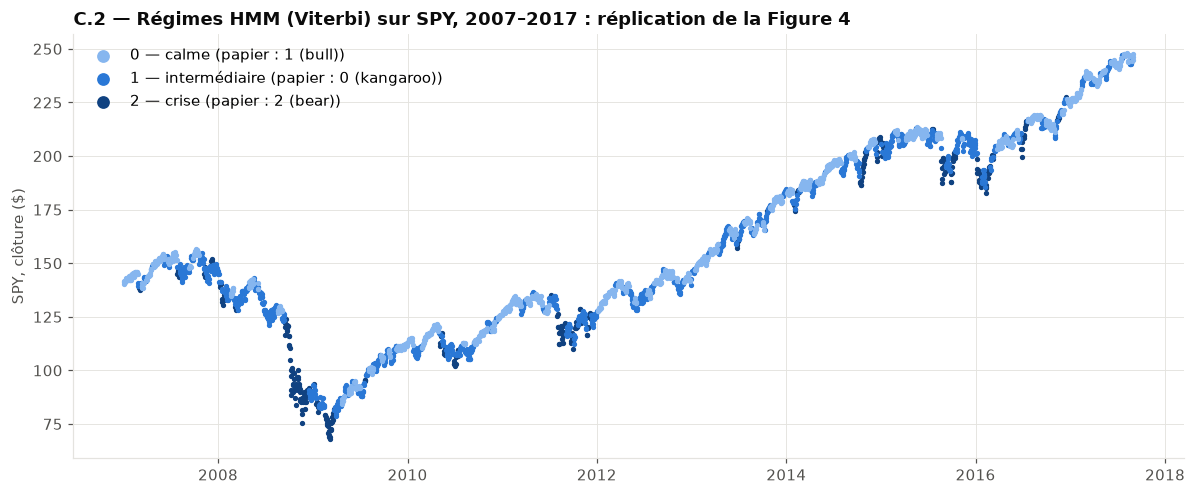

In [9]:
fig, ax = plt.subplots(figsize=(11, 4.6))
px = close_raw.loc[train.index]
for k in range(3):
    sel = viterbi == k
    ax.scatter(px.index[sel], px[sel], s=6, color=REGIME_COLORS[k],
               label=f"{k} — {REGIME_NAMES[k]} (papier : {PAPER_LABEL[k]})", zorder=3 - k * 0.1)
ax.set_ylabel("SPY, clôture ($)")
ax.set_title("C.2 — Régimes HMM (Viterbi) sur SPY, 2007–2017 : réplication de la Figure 4")
ax.legend(loc="upper left", markerscale=3)
fig.tight_layout()
savefig(fig, "C2_classification_spy")
plt.show()

Même allure que la Figure 4 : le régime de crise (bleu foncé) couvre 2008–2009, mai 2010,
août 2011, août 2015 et début 2016 ; le régime calme domine les phases de hausse régulière (2013, 2017).

**Les régimes ont-ils un sens économique ?** Oui pour la **volatilité**, beaucoup moins pour le
**rendement**. Le rendement moyen du régime intermédiaire (+0,040 %) est presque égal à celui du
régime calme (+0,046 %). L'erreur-type d'une moyenne journalière vaut $\sigma/\sqrt{n}$ :

In [10]:
g = train.groupby(viterbi.values)["ret"]
se = pd.DataFrame({"ret_moyen_%": g.mean(), "ecart_type_%": g.std(), "n_jours": g.size()})
se["erreur_type_%"] = se["ecart_type_%"] / np.sqrt(se["n_jours"])
se["t_stat"] = se["ret_moyen_%"] / se["erreur_type_%"]
se.index = [REGIME_NAMES[k] for k in se.index]
save_table(se, "C2_significativite_rendements", ".4f")
se

,ret_moyen_%,ecart_type_%,n_jours,erreur_type_%,t_stat
calme,0.0445,0.6584,1199,0.0190,2.3390
intermédiaire,0.0413,1.1310,1142,0.0335,1.2343
crise,-0.0660,2.6423,345,0.1423,-0.4640


Seul le régime calme a un rendement moyen significativement positif (t ≈ 2,3). Celui du régime
intermédiaire ne l'est pas (t ≈ 1,2), et surtout la moyenne **négative** du régime « bear »
n'est pas significative (t ≈ −0,5 : erreur-type de 0,14 % pour une moyenne de −0,07 %).
L'écart entre calme et intermédiaire (0,003 %) est dix fois plus petit que les erreurs-types. Le HMM
sépare des **niveaux de volatilité** (écarts-types journaliers ≈ 0,66 / 1,13 / 2,64 %) ; appeler
ces régimes « bull », « kangaroo » et « bear » est une interprétation fragile. De plus, cette moyenne est calculée sur les **mêmes jours** que ceux qui ont servi à
classer : un jour de forte baisse fait monter la variance, donc tend à être classé en crise.
Cette relation n'est pas exploitable pour trader (partie D).

## C.3 — Nombre d'états : log-vraisemblance vs BIC

Le papier (Figure 3) choisit 3 états en regardant la **log-vraisemblance** seule, qui augmente
forcément avec le nombre d'états (modèles emboîtés). Le BIC pénalise la complexité :
$\mathrm{BIC} = -2\log L + p\ln T$ avec, pour $K$ états, $d = 2$ variables et covariance pleine,
$p = (K-1) + K(K-1) + Kd + K\,d(d+1)/2$ paramètres libres.

In [11]:
rows = []
for K in range(2, 7):
    mk = fit_hmm(Z.values, K, n_init=10)
    ll, aic, bic = information_criteria(mk, Z.values)
    mk_s, _ = sort_states(mk, "mean", 1)
    pi_s = stationary_distribution(mk_s.transmat_)
    rows.append({"K": K, "p": n_params(K, 2), "log-vrais. (standardisé)": ll,
                 "log-vrais. (unités brutes)": ll - jac, "AIC": aic, "BIC": bic,
                 "durée moy. pondérée (j)": (pi_s * expected_durations(mk_s.transmat_)).sum(),
                 "durée min (j)": expected_durations(mk_s.transmat_).min()})
bic_tab = pd.DataFrame(rows).set_index("K")
bic_tab["BIC - BIC min"] = bic_tab["BIC"] - bic_tab["BIC"].min()
save_table(bic_tab, "C3_bic_nombre_etats", ".1f")
bic_tab

,p,log-vrais. (standardisé),log-vrais. (unités brutes),AIC,BIC,durée moy. pondérée (j),durée min (j),BIC - BIC min
K,,,,,,,,
2,13,-4428.2379,-9905.5642,8882.4758,8959.1214,37.1778,11.6158,4710.6466
3,23,-3137.2949,-8614.6212,6320.5898,6456.1934,12.7103,9.2277,2207.7186
4,35,-2531.3238,-8008.6501,5132.6476,5339.0009,7.5779,5.2723,1090.5261
5,49,-2092.9167,-7570.2430,4283.8333,4572.7279,7.0321,5.0868,324.2532
6,65,-1867.6236,-7344.9499,3865.2472,4248.4747,5.8925,3.0263,0.0000


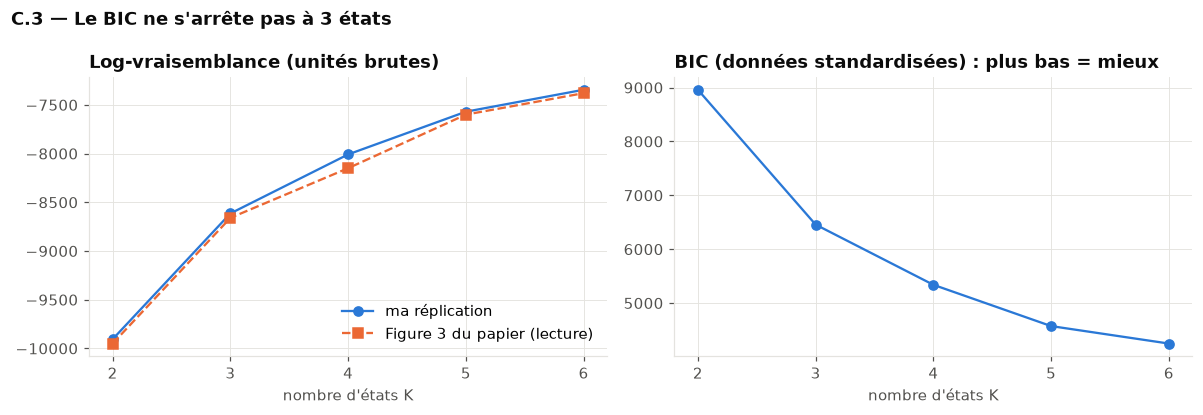

In [12]:
paper_fig3 = pd.Series([-9950, -8660, -8150, -7600, -7380], index=range(2, 7))  # lu sur la Figure 3
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
axes[0].plot(bic_tab.index, bic_tab["log-vrais. (unités brutes)"], marker="o", color=CATEGORICAL[0], label="ma réplication")
axes[0].plot(paper_fig3.index, paper_fig3, marker="s", ls="--", color=CATEGORICAL[1], label="Figure 3 du papier (lecture)")
axes[0].set_title("Log-vraisemblance (unités brutes)")
axes[0].set_xlabel("nombre d'états K")
axes[0].legend(loc="lower right")
axes[1].plot(bic_tab.index, bic_tab["BIC"], marker="o", color=CATEGORICAL[0])
axes[1].set_title("BIC (données standardisées) : plus bas = mieux")
axes[1].set_xlabel("nombre d'états K")
for ax in axes:
    ax.set_xticks(range(2, 7))
fig.suptitle("C.3 — Le BIC ne s'arrête pas à 3 états", x=0.01, ha="left", fontweight="bold", color="#0b0b0b")
fig.tight_layout()
savefig(fig, "C3_loglik_bic")
plt.show()

Ma courbe de log-vraisemblance reproduit la Figure 3 du papier (−9 906 ; −8 615 ; −8 009 ;
−7 570 ; −7 345 contre ≈ −9 950 ; −8 660 ; −8 150 ; −7 600 ; −7 380).

**Le BIC ne conclut pas comme les auteurs** : il diminue encore à 4, 5 et 6 états. Chaque état
supplémentaire fait gagner plusieurs centaines de points de log-vraisemblance, alors que la
pénalité n'est que de $\ln(2686) \approx 7{,}9$ par paramètre. Sur données simulées (notebook 01),
le BIC retrouvait pourtant le bon nombre d'états. Deux hypothèses du HMM sont violées ici :
1. **Émissions non gaussiennes** : la « vol » est positive, très asymétrique, et les rendements
   ont des queues épaisses. Le modèle ajoute des états pour approcher ces lois par des mélanges de gaussiennes.
2. **Observations dépendantes à l'intérieur d'un état** : $v_t$ est calculée sur 10 jours
   glissants, donc $v_t$ et $v_{t+1}$ partagent 9 prix sur 10. Le HMM suppose au contraire les
   observations indépendantes sachant l'état ; il explique cette forte persistance en multipliant
   les états. L'information réelle est bien plus faible que $T = 2\,686$ observations
   indépendantes, et la pénalité $\ln T$ du BIC est trop faible. Je le vérifie ci-dessous :

In [13]:
resid = Z["vol"] - pd.Series(model.means_[viterbi.values, 1], index=Z.index)
ac = pd.Series({REGIME_NAMES[k]: resid[viterbi == k].autocorr(lag=1) for k in range(3)},
               name="autocorrélation d'ordre 1 de la vol. dans chaque régime")
ac.to_frame()

,autocorrélation d'ordre 1 de la vol. dans chaque régime
calme,0.8120
intermédiaire,0.7419
crise,0.9293


Même à l'intérieur d'un régime, la variable « vol » a une autocorrélation d'ordre 1 comprise entre
0,74 et 0,93, alors que le modèle suppose 0. L'hypothèse d'indépendance conditionnelle est
clairement fausse.

**Mon choix : je garde K = 3**, mais pour d'autres raisons que le papier. Le BIC ne peut pas
trancher proprement parce que le modèle est mal spécifié. Le choix repose donc sur :
- l'**interprétabilité** : trois niveaux de volatilité (calme / intermédiaire / crise) ;
- la **persistance** : avec 5 ou 6 états, certains régimes ne durent en moyenne que quelques
  jours (colonne « durée min »), ce qui multiplierait les changements d'allocation et les frais ;
- la **stabilité** dans le walk-forward : 23 paramètres à réestimer chaque mois au lieu de 65.

Ce choix reste un jugement, ce que le papier ne dit pas clairement. Le BIC donne une
réponse différente, et je la signale.

## C.4 — Le HMM fait-il mieux que des méthodes simples ?

- **KMeans à 3 groupes** sur les mêmes variables standardisées (groupes triés par volatilité) ;
- **règle manuelle** : crise si la vol dépasse son **90ᵉ centile historique**. J'utilise le centile
  calculé sur tout l'historique **disponible à la date t** (depuis 1993) pour que la règle soit
  causale, donc comparable à une règle utilisable en temps réel.

In [14]:
km_lab, km = kmeans_regimes(Z, 3)
rule_full = vol_threshold_regime(F_paper["vol"], q=0.90, expanding=True)
rule = rule_full.loc[train.index]
hmm_filt_lab = pd.Series(filt.values.argmax(1), index=train.index)

methods = {"HMM Viterbi (voit le futur)": viterbi, "HMM filtré (causal)": hmm_filt_lab,
           "KMeans": km_lab}
comp = []
for name, lab in methods.items():
    pt = persistence_table(lab)
    comp.append({"méthode": name, "changements / an": n_switches_per_year(lab),
                 "% jours en crise": (lab == 2).mean(),
                 "durée moy. calme (j)": pt.loc[0, "duree_moyenne_j"],
                 "durée moy. interm. (j)": pt.loc[1, "duree_moyenne_j"],
                 "durée moy. crise (j)": pt.loc[2, "duree_moyenne_j"],
                 "ARI vs HMM Viterbi": adjusted_rand_score(viterbi, lab)})
pt_rule = persistence_table(rule)
comp.append({"méthode": "Règle vol > 90e centile", "changements / an": n_switches_per_year(rule),
             "% jours en crise": rule.mean(), "durée moy. calme (j)": np.nan,
             "durée moy. interm. (j)": np.nan, "durée moy. crise (j)": pt_rule.loc[1, "duree_moyenne_j"],
             "ARI vs HMM Viterbi": adjusted_rand_score((viterbi == 2).astype(int), rule.astype(int))})
comp = pd.DataFrame(comp).set_index("méthode")
save_table(comp, "C4_comparaison_methodes", ".2f")
comp

,changements / an,% jours en crise,durée moy. calme (j),durée moy. interm. (j),durée moy. crise (j),ARI vs HMM Viterbi
méthode,,,,,,
HMM Viterbi (voit le futur),20.0774,0.1284,17.1286,10.6729,9.0789,1.0000
HMM filtré (causal),24.2055,0.1281,13.6395,9.0620,7.8182,0.7932
KMeans,81.3418,0.0082,4.8403,1.3264,5.5000,0.0597
Règle vol > 90e centile,12.0089,0.1549,NaN,NaN,6.5000,0.8261


In [15]:
print("Tableau croisé HMM Viterbi (lignes) x KMeans (colonnes), en nombre de jours :")
ct = pd.crosstab(viterbi.rename("HMM Viterbi"), km_lab.rename("KMeans"))
ct.index = [REGIME_NAMES[k] for k in ct.index]
ct.columns = [REGIME_NAMES[k] for k in ct.columns]
display(ct)
print("Part de jours en HAUSSE dans chaque groupe du KMeans :")
display(train["ret"].gt(0).groupby(km_lab.map(REGIME_NAMES)).mean().rename("% jours en hausse").to_frame())
print("Tableau croisé crise HMM (Viterbi) x règle vol > 90e centile :")
display(pd.crosstab((viterbi == 2).map({True: "HMM crise", False: "HMM pas crise"}).rename("HMM"),
                    rule.map({1.0: "règle crise", 0.0: "règle pas crise"}).rename("règle")))

Tableau croisé HMM Viterbi (lignes) x KMeans (colonnes), en nombre de jours :


,calme,intermédiaire,crise
calme,1036,163,0
intermédiaire,865,277,0
crise,190,133,22


Part de jours en HAUSSE dans chaque groupe du KMeans :


,% jours en hausse
kmeans,
calme,0.6896
crise,0.4091
intermédiaire,0.0035


Tableau croisé crise HMM (Viterbi) x règle vol > 90e centile :


règle,règle crise,règle pas crise
HMM,,
HMM crise,336,9
HMM pas crise,80,2261


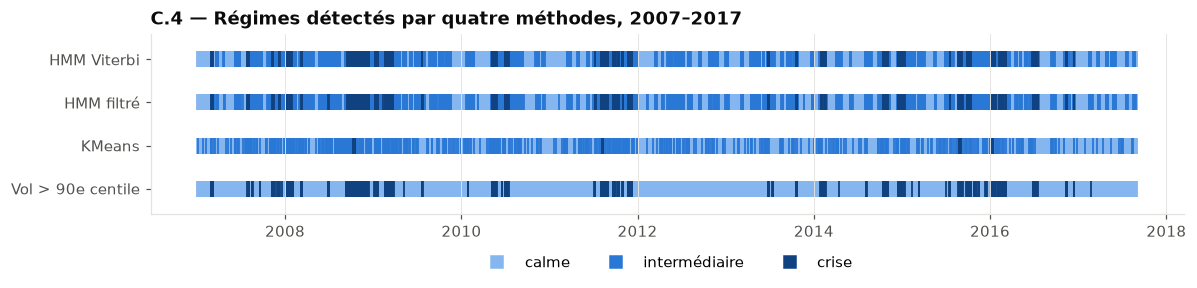

In [16]:
fig, ax = plt.subplots(figsize=(11, 2.8))
rows_plot = [("HMM Viterbi", viterbi), ("HMM filtré", hmm_filt_lab), ("KMeans", km_lab),
             ("Vol > 90e centile", rule.map({0.0: 0, 1.0: 2}))]
for i, (name, lab) in enumerate(rows_plot):
    for k in range(3):
        sel = lab == k
        ax.scatter(lab.index[sel], np.full(sel.sum(), -i), marker="|", s=120, color=REGIME_COLORS[k], lw=1.2)
ax.set_yticks([-i for i in range(len(rows_plot))], [r[0] for r in rows_plot])
ax.set_ylim(-len(rows_plot) + 0.4, 0.6)
ax.grid(axis="y", visible=False)
handles = [plt.Line2D([], [], color=REGIME_COLORS[k], marker="s", ls="", ms=8, label=REGIME_NAMES[k]) for k in range(3)]
ax.legend(handles=handles, loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=3)
ax.set_title("C.4 — Régimes détectés par quatre méthodes, 2007–2017")
fig.tight_layout()
savefig(fig, "C4_comparaison_methodes")
plt.show()

**Ce que montre la comparaison.**
- **La règle de seuil retrouve presque exactement les crises du HMM** : 336 des 345 jours de crise
  du HMM (97 %) sont aussi au-dessus du 90ᵉ centile (ARI = 0,83 sur la dimension crise / pas crise).
  La règle signale en plus 80 jours, surtout en fin d'échantillon, où le niveau de prix plus élevé
  gonfle la variable du papier. Pour repérer les périodes agitées, un seul seuil fait presque
  aussi bien que le HMM.
- **Le KMeans échoue complètement** (ARI = 0,06, 81 changements de groupe par an). Son groupe
  « crise » ne contient que 22 jours extrêmes d'octobre–novembre 2008 : la variable de vol est si
  asymétrique (max ≈ 15 écarts-types) que ces quelques jours forment un groupe à eux seuls. Le reste est
  coupé selon **le signe du rendement** : 0 % de jours en hausse dans le groupe « intermédiaire »,
  69 % dans le groupe « calme ». Or le signe du rendement journalier n'a aucune persistance, d'où
  les changements incessants. Le KMeans ne compare que des **centres** ; il ne sait pas
  utiliser la **dispersion**. Le HMM, lui, modélise une variance propre à chaque état : un rendement
  de ±3 % renseigne sur l'état par sa taille, pas par son signe.
- **Persistance** : le HMM filtré (causal) change de régime 24 fois par an, et Viterbi 20 fois (il utilise
  le futur pour « boucher les trous »), contre 81 pour le KMeans. La règle binaire change 12 fois
  par an, mais elle n'a que deux états. Grâce à sa matrice de transition, le HMM exige davantage
  d'évidence avant de changer d'avis.

**Le HMM apporte-t-il vraiment quelque chose ?** Pour *identifier* les crises, pas beaucoup : un
seuil sur la volatilité, avec un seul paramètre, fait presque aussi bien. Face à un
clustering naïf, en revanche, l'apport est net : il vient de la modélisation de la variance par état et
de la persistance (matrice de transition), qui évitent de confondre « jour de baisse » et « régime
de crise ». Il fournit aussi (1) une **probabilité** plutôt qu'une étiquette, utile pour des règles
d'hystérésis (D.4), et (2) une **prédiction** du régime du lendemain via $A$. Tout cela ne vaut
que si le modèle est à peu près bien spécifié, ce qui n'est pas le cas avec la variable de
volatilité du papier (C.1, C.3).